In [1]:
import json
import os
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

sys.path.append(str(Path.cwd().parent))
from src.utils import get_project_root, download_preprocessed_dataset

RANDOM_SEED = 42

In [2]:
PROJECT_ROOT = get_project_root()
PREPROCESSED_DATASET_PATH = PROJECT_ROOT / "data" / "preprocessed" / "clean_data.parquet"
ARTIFACTS_PATH = PROJECT_ROOT / "artifacts" / "baselines"
os.makedirs(ARTIFACTS_PATH, exist_ok=True)

In [3]:
try:
    df = pd.read_parquet(PREPROCESSED_DATASET_PATH)
except FileNotFoundError:
    try:
        download_preprocessed_dataset()
        df = pd.read_parquet(PREPROCESSED_DATASET_PATH)
    except Exception as ex:
        print(f"Ошибка: {ex}")

In [4]:
df.head()

,news,labels,category_name,text_len,words_count,news_tfidf_ready
0,"Российские пожарные спасли детеныша косули, по...",0,Климат,1240,185,российский пожарный спасти детёныш косуля попа...
1,Житель Сахалина заметил на острове орлана — кр...,0,Климат,858,129,житель сахалин заметить остров орлан крупный х...
2,Российские заводы начнут работать по-новому ра...,0,Климат,1117,140,российский завод начать работать спасение план...
3,Неравнодушные россияне спасли слепого и глухог...,0,Климат,999,156,неравнодушный россиянин спасти слепой глухой е...
4,Специалисты предупредили граждан Британии о во...,0,Климат,1914,256,специалист предупредить гражданин британия воз...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70875 entries, 0 to 70874
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   news              70875 non-null  object
 1   labels            70875 non-null  int32 
 2   category_name     70875 non-null  object
 3   text_len          70875 non-null  int64 
 4   words_count       70875 non-null  int64 
 5   news_tfidf_ready  70875 non-null  object
dtypes: int32(1), int64(2), object(3)
memory usage: 3.0+ MB


In [6]:
X = df["news_tfidf_ready"]
y = df["labels"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)

In [8]:
metrics = {}

def log_metrics(
    model,
    title
) -> None:

    """
    Считает Accuracy и F1-score для заданной модели на test и сохраняет в metrics 
    """
    
    metrics[title] = {
        "accuracy": accuracy_score(y_test, model.predict(X_test)),
        "f1_macro": f1_score(y_test, model.predict(X_test), average="macro"),
        "f1_weighted": f1_score(y_test, model.predict(X_test), average="weighted")
    }

    print(f"========== {title} ==========")
    
    print(f"Accuracy: {metrics[title]['accuracy']}")
    print(f"F1-macro: {metrics[title]['f1_macro']}")
    print(f"F1-weighted: {metrics[title]['f1_weighted']}")

    print(f"=========={'=' * (len(title) + 2)}==========")

In [9]:
class_names = df.groupby('labels')['category_name'].first().values


def evaluate_model(
    model,
    model_name
) -> None:

    """
    Строит confusion matrix и csv отчет по classification report для заданной модели на test
    """
    
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(ARTIFACTS_PATH / f"{model_name}_confusion_matrix.png", dpi=150)
    plt.show()
    
    print("\n" + "="*60)
    print(f"Classification Report - {model_name}")
    print("="*60)
    print(classification_report(y_test, y_pred, target_names=class_names))

    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    class_rows = [cn for cn in class_names if cn in report_df.index]
    class_df = report_df.loc[class_rows].copy()
    class_df["support"] = class_df["support"].astype(int)

    out_df = class_df.reset_index().rename(columns={'index': 'class'})
    out_path = ARTIFACTS_PATH / f"{model_name}_class_report.csv"
    out_df.to_csv(out_path, index=False)


## Baseline 1 - DummyClassifier
Определяет класс случайным образом

In [10]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_SEED)
dummy.fit(X_train, y_train)

,strategy,'stratified'
,random_state,42
,constant,None


In [11]:
log_metrics(dummy, "DummyClassifier")

========== DummyClassifier ==========
Accuracy: 0.09700176366843033
F1-macro: 0.09352783696405341
F1-weighted: 0.09705672279565163


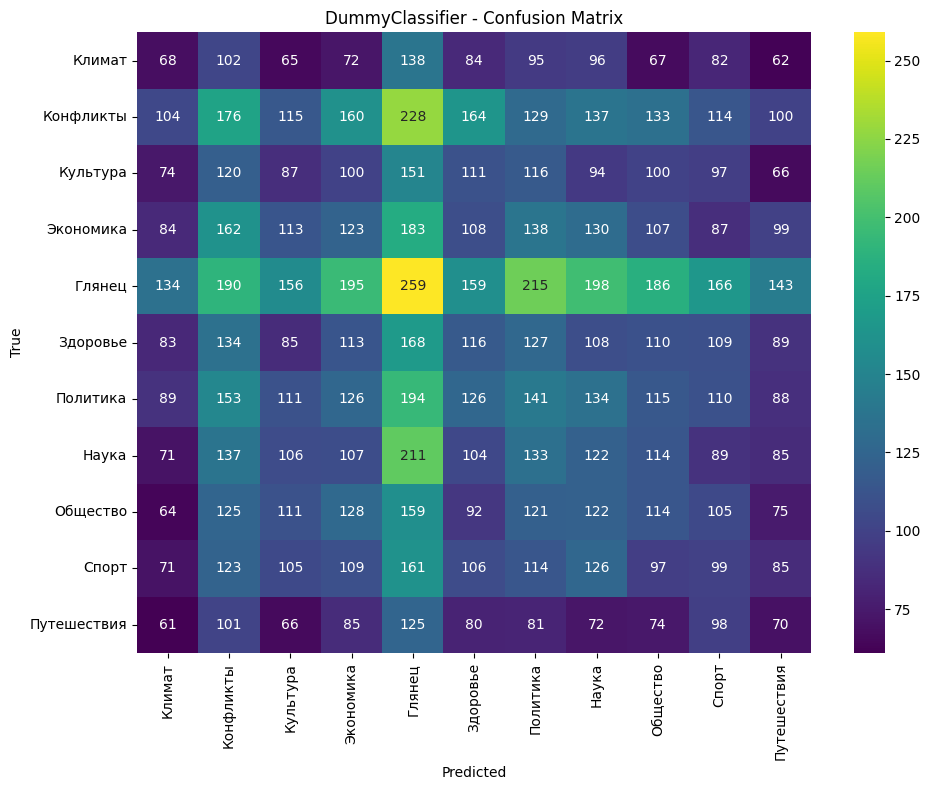


Classification Report - DummyClassifier
              precision    recall  f1-score   support

      Климат       0.08      0.07      0.07       931
   Конфликты       0.12      0.11      0.11      1560
    Культура       0.08      0.08      0.08      1116
   Экономика       0.09      0.09      0.09      1334
      Глянец       0.13      0.13      0.13      2001
    Здоровье       0.09      0.09      0.09      1242
    Политика       0.10      0.10      0.10      1387
       Наука       0.09      0.10      0.09      1279
    Общество       0.09      0.09      0.09      1216
       Спорт       0.09      0.08      0.08      1196
 Путешествия       0.07      0.08      0.07       913

    accuracy                           0.10     14175
   macro avg       0.09      0.09      0.09     14175
weighted avg       0.10      0.10      0.10     14175



In [12]:
evaluate_model(dummy, "DummyClassifier")

## Baseline 2 - Pipeline(TF-IDF + Naive Bayes)
- TF-IDF кодирует слова в признаки по принципу частоты их вхождения
- Наивный Байес предсказывает класс на вероятностной основе `P(слово | класс)`

In [13]:
nb_pipeline = Pipeline([
    ("vec", TfidfVectorizer(max_features=50_000, ngram_range=(1,2))),
    ("nb", MultinomialNB())
])
nb_pipeline.fit(X_train, y_train)

,steps,"[('vec', ...), ('nb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [14]:
log_metrics(nb_pipeline, "MultinomialNB")

========== MultinomialNB ==========
Accuracy: 0.7991534391534392
F1-macro: 0.8066511193379895
F1-weighted: 0.7962669289582203


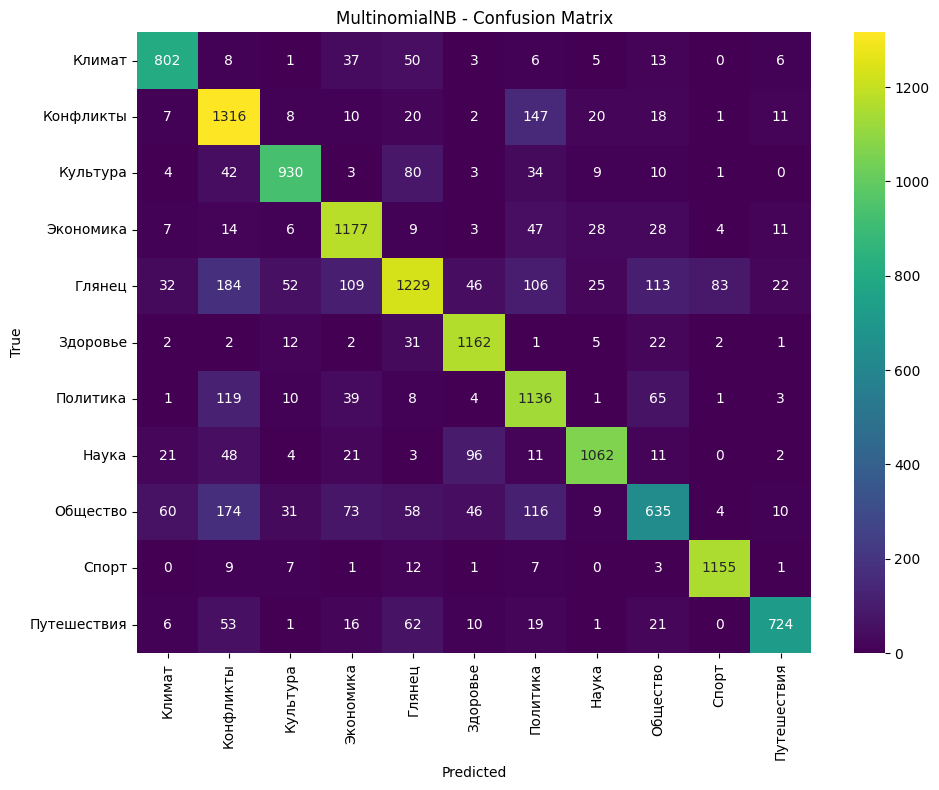


Classification Report - MultinomialNB
              precision    recall  f1-score   support

      Климат       0.85      0.86      0.86       931
   Конфликты       0.67      0.84      0.75      1560
    Культура       0.88      0.83      0.85      1116
   Экономика       0.79      0.88      0.83      1334
      Глянец       0.79      0.61      0.69      2001
    Здоровье       0.84      0.94      0.89      1242
    Политика       0.70      0.82      0.75      1387
       Наука       0.91      0.83      0.87      1279
    Общество       0.68      0.52      0.59      1216
       Спорт       0.92      0.97      0.94      1196
 Путешествия       0.92      0.79      0.85       913

    accuracy                           0.80     14175
   macro avg       0.81      0.81      0.81     14175
weighted avg       0.80      0.80      0.80     14175



In [15]:
evaluate_model(nb_pipeline, "MultinomialNB")

## Baseline 3 - Pipeline(TF-IDF + LogReg)

In [16]:
lr_pipeline = Pipeline([
    ("vec", TfidfVectorizer(max_features=50_000, ngram_range=(1,2))),
    ("lr", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
])
lr_pipeline.fit(X_train, y_train)

,steps,"[('vec', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [17]:
log_metrics(lr_pipeline, "LogisticRegression")

========== LogisticRegression ==========
Accuracy: 0.8470546737213404
F1-macro: 0.852668393888189
F1-weighted: 0.8465811350744252


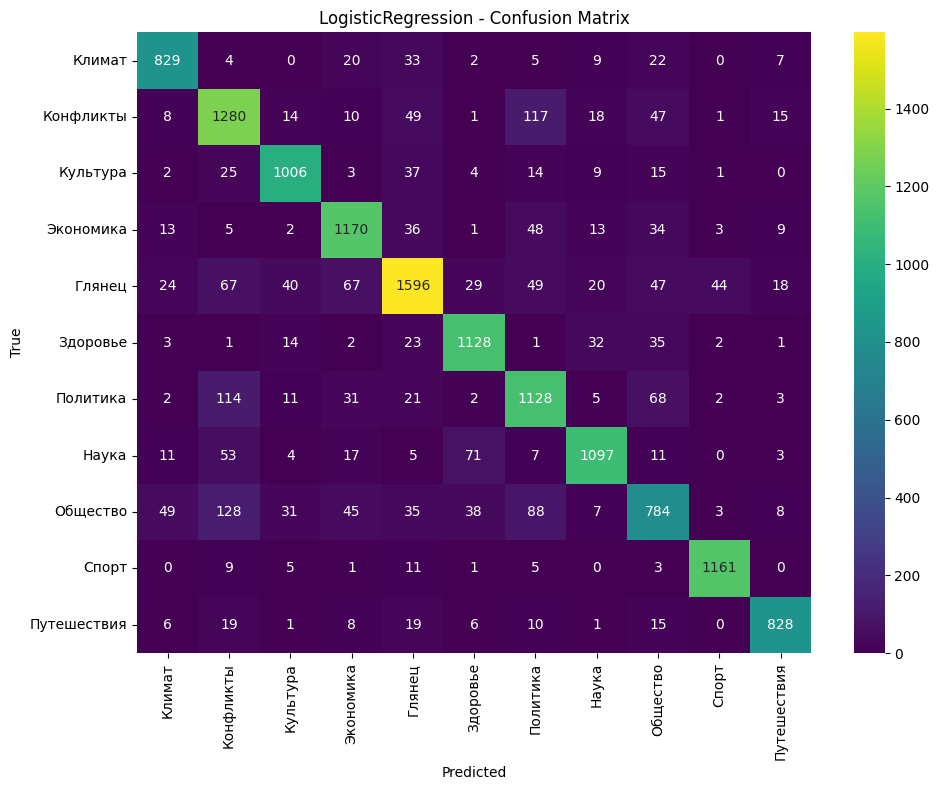


Classification Report - LogisticRegression
              precision    recall  f1-score   support

      Климат       0.88      0.89      0.88       931
   Конфликты       0.75      0.82      0.78      1560
    Культура       0.89      0.90      0.90      1116
   Экономика       0.85      0.88      0.86      1334
      Глянец       0.86      0.80      0.83      2001
    Здоровье       0.88      0.91      0.89      1242
    Политика       0.77      0.81      0.79      1387
       Наука       0.91      0.86      0.88      1279
    Общество       0.73      0.64      0.68      1216
       Спорт       0.95      0.97      0.96      1196
 Путешествия       0.93      0.91      0.92       913

    accuracy                           0.85     14175
   macro avg       0.85      0.85      0.85     14175
weighted avg       0.85      0.85      0.85     14175



In [18]:
evaluate_model(lr_pipeline, "LogisticRegression")

## Baseline 4 - Pipeline(TF-IDF + SVM)

In [19]:
svm_pipeline = Pipeline([
    ("vec", TfidfVectorizer(max_features=50_000, ngram_range=(1,2))),
    ("svm", LinearSVC(random_state=RANDOM_SEED))
])
svm_pipeline.fit(X_train, y_train)

,steps,"[('vec', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [20]:
log_metrics(svm_pipeline, "LinearSVC")

========== LinearSVC ==========
Accuracy: 0.8591181657848325
F1-macro: 0.8634853300364601
F1-weighted: 0.8582172779857434


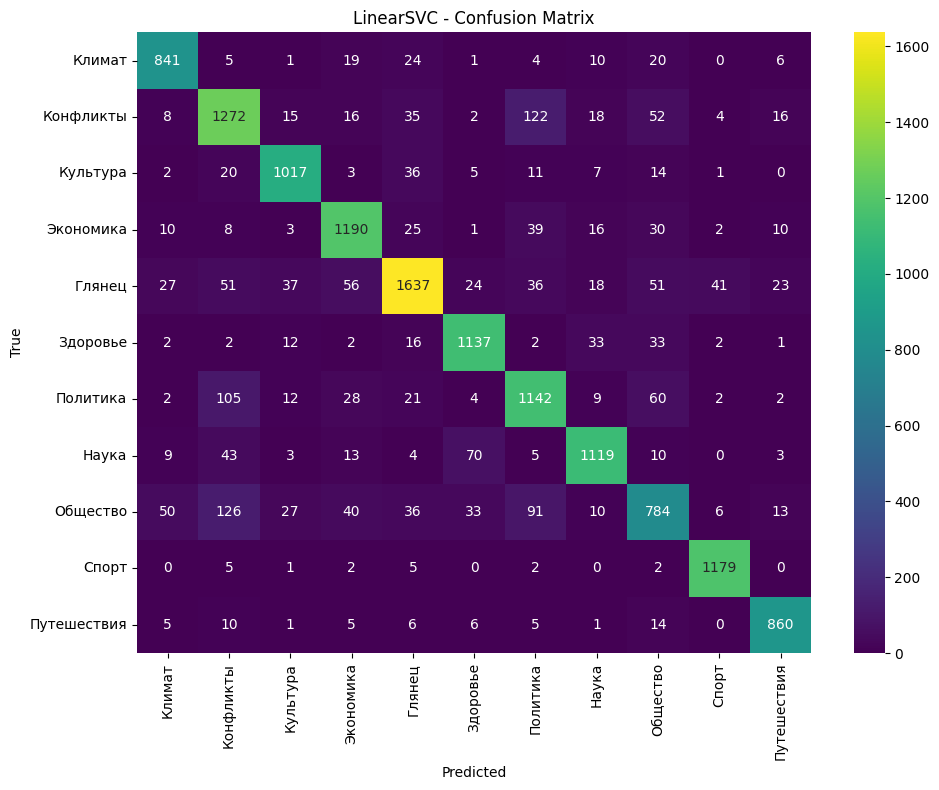


Classification Report - LinearSVC
              precision    recall  f1-score   support

      Климат       0.88      0.90      0.89       931
   Конфликты       0.77      0.82      0.79      1560
    Культура       0.90      0.91      0.91      1116
   Экономика       0.87      0.89      0.88      1334
      Глянец       0.89      0.82      0.85      2001
    Здоровье       0.89      0.92      0.90      1242
    Политика       0.78      0.82      0.80      1387
       Наука       0.90      0.87      0.89      1279
    Общество       0.73      0.64      0.69      1216
       Спорт       0.95      0.99      0.97      1196
 Путешествия       0.92      0.94      0.93       913

    accuracy                           0.86     14175
   macro avg       0.86      0.87      0.86     14175
weighted avg       0.86      0.86      0.86     14175



In [21]:
evaluate_model(svm_pipeline, "LinearSVC")

In [22]:
pd.DataFrame(metrics)

,DummyClassifier,MultinomialNB,LogisticRegression,LinearSVC
accuracy,0.097002,0.799153,0.847055,0.859118
f1_macro,0.093528,0.806651,0.852668,0.863485
f1_weighted,0.097057,0.796267,0.846581,0.858217


## Подбор оптимальных гиперпараметров лучшего baseline

In [23]:
pipe = Pipeline([
    ("vec", TfidfVectorizer(sublinear_tf=True)),
    ("svm", LinearSVC(random_state=RANDOM_SEED))
])

param_grid = {
    # TF-IDF
    "vec__ngram_range": [(1, 2)],
    "vec__max_features": [30000, 50000, 70000],
    "vec__min_df": [3, 5],
    "vec__max_df": [0.8, 0.9],

    #SVM
    "svm__C": [0.1, 0.3, 1, 3, 5],
    "svm__loss": ["squared_hinge"],
    "svm__class_weight": [None, "balanced"]
}


grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    verbose=2
)


In [24]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'svm__C': [0.1, 0.3, ...], 'svm__class_weight': [None, 'balanced'], 'svm__loss': ['squared_hinge'], 'vec__max_df': [0.8, 0.9], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [25]:
print("Best score:", grid.best_score_)
print("Best params:", grid.best_params_)

Best score: 0.8632721765725986
Best params: {'svm__C': 0.3, 'svm__class_weight': None, 'svm__loss': 'squared_hinge', 'vec__max_df': 0.8, 'vec__max_features': 70000, 'vec__min_df': 3, 'vec__ngram_range': (1, 2)}


In [26]:
log_metrics(grid.best_estimator_, "LinearSVC Tuned")

========== LinearSVC Tuned ==========
Accuracy: 0.8621516754850088
F1-macro: 0.8661472102423606
F1-weighted: 0.860907901293414


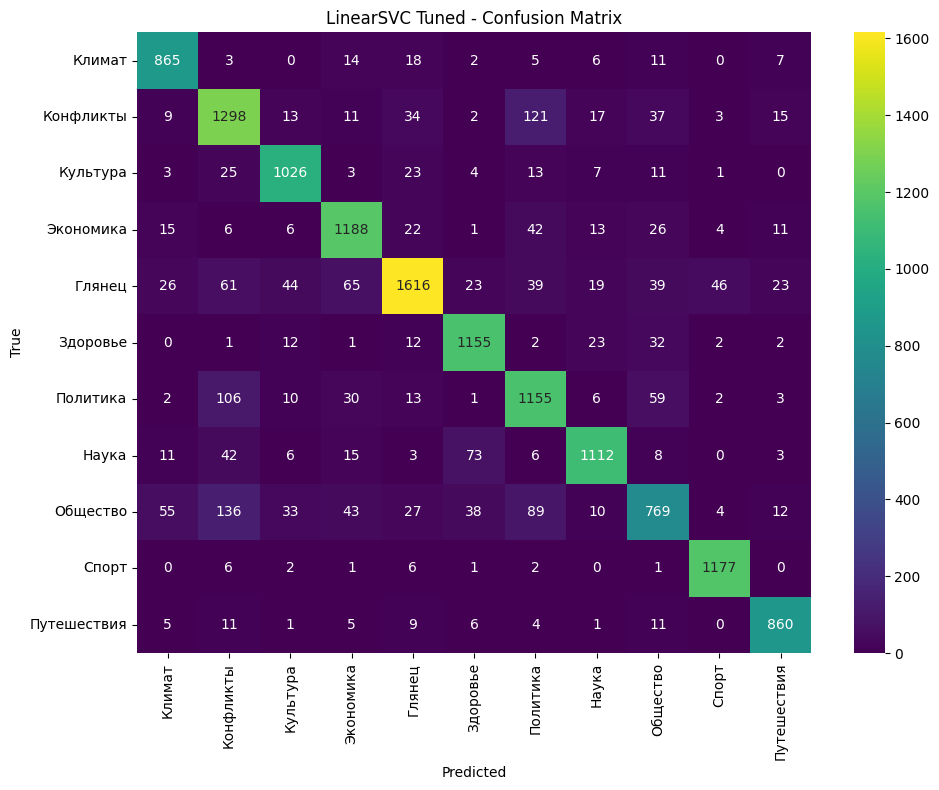


Classification Report - LinearSVC Tuned
              precision    recall  f1-score   support

      Климат       0.87      0.93      0.90       931
   Конфликты       0.77      0.83      0.80      1560
    Культура       0.89      0.92      0.90      1116
   Экономика       0.86      0.89      0.88      1334
      Глянец       0.91      0.81      0.85      2001
    Здоровье       0.88      0.93      0.91      1242
    Политика       0.78      0.83      0.81      1387
       Наука       0.92      0.87      0.89      1279
    Общество       0.77      0.63      0.69      1216
       Спорт       0.95      0.98      0.97      1196
 Путешествия       0.92      0.94      0.93       913

    accuracy                           0.86     14175
   macro avg       0.86      0.87      0.87     14175
weighted avg       0.86      0.86      0.86     14175



In [27]:
evaluate_model(grid.best_estimator_, "LinearSVC Tuned")

In [28]:
pd.DataFrame(metrics)

,DummyClassifier,MultinomialNB,LogisticRegression,LinearSVC,LinearSVC Tuned
accuracy,0.097002,0.799153,0.847055,0.859118,0.862152
f1_macro,0.093528,0.806651,0.852668,0.863485,0.866147
f1_weighted,0.097057,0.796267,0.846581,0.858217,0.860908


In [29]:
joblib.dump(grid.best_estimator_, ARTIFACTS_PATH / "svm_best_model.joblib")

with (
        open(ARTIFACTS_PATH / "svm_best_params.json", mode="w", encoding="utf-8") as best_config,
        open(ARTIFACTS_PATH / "baselines_metrics.json", mode="w", encoding="utf-8") as baselines_metrics,
):
    json.dump(grid.best_params_, best_config)
    json.dump(pd.DataFrame(metrics).to_dict(), baselines_metrics)